# Part 1 — Data Loading, Preprocessing, and EDA

**Project:** End-to-End NLP Pipeline for Drug Review Analysis  
**Dataset:** `drugLibTrain_raw.tsv` and `drugLibTest_raw.tsv`

This notebook prepares the Drug Review dataset for the later project sections:

- sentiment analysis,
- text classification,
- and BM25 information retrieval.

The goal is to create clean, model-ready review text while also documenting the dataset schema, class balance, vocabulary and review length patterns.


## 1. Setup and imports

This cell imports the libraries used for data loading, text cleaning, tokenization, lemmatization and visualization.


In [1]:
import os
import re
import html
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

try:
    import nltk
except Exception:
    nltk = None

pd.set_option("display.max_colwidth", 120)


# Robust NLP helpers: NLTK will be used when available, otherwise use small built-in fallbacks.
BASIC_STOPWORDS = {
    "a","an","the","and","or","but","if","while","of","at","by","for","with","about","against","between",
    "into","through","during","before","after","above","below","to","from","up","down","in","out","on",
    "off","over","under","again","further","then","once","here","there","when","where","why","how","all",
    "any","both","each","few","more","most","other","some","such","own","same","so","than","too","very",
    "can","will","just","should","now","is","am","are","was","were","be","been","being","have","has",
    "had","having","do","does","did","doing","this","that","these","those","i","me","my","myself","we",
    "our","ours","ourselves","you","your","yours","yourself","yourselves","he","him","his","himself",
    "she","her","hers","herself","it","its","itself","they","them","their","theirs","themselves",
    "what","which","who","whom","because","as","until","also"
}

def get_stopwords():
    try:
        from nltk.corpus import stopwords
        words = set(stopwords.words("english"))
    except Exception:
        words = set(BASIC_STOPWORDS)
    # Keep negation words because they matter in sentiment analysis.
    for neg_word in ["no", "not", "nor", "never"]:
        words.discard(neg_word)
    return words

try:
    from nltk.stem import WordNetLemmatizer
    _wordnet_lemmatizer = WordNetLemmatizer()
    # Test if WordNet data exists.
    _ = _wordnet_lemmatizer.lemmatize("tests")
    def simple_lemma(token):
        return _wordnet_lemmatizer.lemmatize(token)
except Exception:
    def simple_lemma(token):
        # Lightweight fallback for offline environments.
        if len(token) > 4 and token.endswith("ies"):
            return token[:-3] + "y"
        if len(token) > 4 and token.endswith("ing"):
            return token[:-3]
        if len(token) > 3 and token.endswith("ed"):
            return token[:-2]
        if len(token) > 3 and token.endswith("s"):
            return token[:-1]
        return token

stop_words = get_stopwords()


## 2. Load the raw train and test files

The uploaded DrugLib files are tab-separated files, so they are loaded using `sep="\t"`.  
A `split` column is added so we can combine the files for EDA while still keeping track of the original train/test source.


In [2]:
TRAIN_PATH = "data/raw/drugLibTrain_raw.tsv"
TEST_PATH = "data/raw/drugLibTest_raw.tsv"

train_df = pd.read_csv(TRAIN_PATH, sep="\t")
test_df = pd.read_csv(TEST_PATH, sep="\t")

train_df["split"] = "train"
test_df["split"] = "test"

df = pd.concat([train_df, test_df], ignore_index=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Combined shape:", df.shape)
display(df.head())


Train shape: (3107, 10)
Test shape: (1036, 10)
Combined shape: (4143, 10)


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview,split
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dysfunction into overt heart failure \r\r\nalone or with other agents in ...,"cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonit...","monitor blood pressure , weight and asses for resolution of fluid",train
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,"Although this type of birth control has more cons than pros, it did help with my cramps. It's also effective with th...","Heavy Cycle, Cramps, Hot Flashes, Fatigue, Long Lasting Cycles. It's only been 5 1/2 months, but i'm concidering cha...","I Hate This Birth Control, I Would Not Suggest This To Anyone.",train
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they would leave me balled up in bed for at least 2 days. The Ponstel doe...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cramps and then every 8-12 hours took 1 pill as needed for about 3-4 day...,train
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months after just a few days of being on the drug. The heartburn started again a...,"Constipation, dry mouth and some mild dizziness that would go away after medication was stopped for a few days.","I was given Prilosec prescription at a dose of 45mg per day. Medication was taken once, every morning before eating....",train
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,"I think that the Lyrica was starting to help with the pain, but the side-effects were just too severe to continue.",I felt extremely drugged and dopey. Could not drive at all while on this med. Also had extreme ankle and feet swel...,See above,train


## 3. Dataset schema

This table explains what each column means and how it will be used in the project.


In [3]:
schema = pd.DataFrame({
    "Column": [
        "Unnamed: 0", "urlDrugName", "rating", "effectiveness", "sideEffects",
        "condition", "benefitsReview", "sideEffectsReview", "commentsReview", "split"
    ],
    "Meaning": [
        "Original dataset row/index identifier",
        "Drug name written in URL-style format",
        "Patient rating score for the medication",
        "Patient-reported effectiveness category",
        "Patient-reported side-effect severity category",
        "Medical condition being treated",
        "Text describing the benefits of the medication",
        "Text describing experienced side effects",
        "Additional patient comments about treatment",
        "Original source file: train or test"
    ],
    "Use in Project": [
        "Can be kept as an ID reference",
        "Useful for EDA, filtering, and BM25 search results",
        "Used to create sentiment labels",
        "Useful as an additional descriptive feature",
        "Useful for side-effect analysis and EDA",
        "Useful for EDA and retrieval filtering",
        "Part of the main review text",
        "Part of the main review text",
        "Part of the main review text",
        "Preserves train/test split"
    ]
})

display(schema)


,Column,Meaning,Use in Project
0,Unnamed: 0,Original dataset row/index identifier,Can be kept as an ID reference
1,urlDrugName,Drug name written in URL-style format,"Useful for EDA, filtering, and BM25 search results"
2,rating,Patient rating score for the medication,Used to create sentiment labels
3,effectiveness,Patient-reported effectiveness category,Useful as an additional descriptive feature
4,sideEffects,Patient-reported side-effect severity category,Useful for side-effect analysis and EDA
5,condition,Medical condition being treated,Useful for EDA and retrieval filtering
6,benefitsReview,Text describing the benefits of the medication,Part of the main review text
7,sideEffectsReview,Text describing experienced side effects,Part of the main review text
8,commentsReview,Additional patient comments about treatment,Part of the main review text
9,split,Original source file: train or test,Preserves train/test split


## 4. Data quality checks

This section checks missing values, duplicates and basic rating distribution.  
These checks help identify whether cleaning or filtering is needed before modeling.


In [4]:
print("Missing values per column:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDuplicate full rows:", df.duplicated().sum())

print("\nRating summary:")
display(df["rating"].describe())

print("\nUnique drugs:", df["urlDrugName"].nunique())
print("Unique conditions:", df["condition"].nunique())


Missing values per column:


,missing_count
Unnamed: 0,0
urlDrugName,0
rating,0
effectiveness,0
sideEffects,0
condition,1
benefitsReview,23
sideEffectsReview,98
commentsReview,13
split,0



Duplicate full rows: 0

Rating summary:


count    4143.000000
mean        6.946416
std         2.948868
min         1.000000
25%         5.000000
50%         8.000000
75%         9.000000
max        10.000000
Name: rating, dtype: float64


Unique drugs: 541
Unique conditions: 1807


## 5. Combine review fields

The DrugLib dataset separates each review into benefits, side effects and comments.  
For modeling, these three text fields are combined into one full review column.


In [5]:
review_columns = ["benefitsReview", "sideEffectsReview", "commentsReview"]

df["full_review"] = (
    df[review_columns]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df[["urlDrugName", "condition", "rating", "full_review"]].head()


,urlDrugName,condition,rating,full_review
0,enalapril,management of congestive heart failure,4,slowed the progression of left ventricular dysfunction into overt heart failure alone or with other agents in the ma...
1,ortho-tri-cyclen,birth prevention,1,"Although this type of birth control has more cons than pros, it did help with my cramps. It's also effective with th..."
2,ponstel,menstrual cramps,10,I was used to having cramps so badly that they would leave me balled up in bed for at least 2 days. The Ponstel does...
3,prilosec,acid reflux,3,The acid reflux went away for a few months after just a few days of being on the drug. The heartburn started again a...
4,lyrica,fibromyalgia,2,"I think that the Lyrica was starting to help with the pain, but the side-effects were just too severe to continue. I..."


## 6. Create sentiment labels from rating

The rating score is converted into three classes:

- negative: rating 1–4  
- neutral: rating 5–6  
- positive: rating 7–10  

This gives a clear target variable for sentiment analysis and text classification.


In [6]:
def rating_to_sentiment(rating):
    if rating <= 4:
        return "negative"
    elif rating <= 6:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)

display(df[["rating", "sentiment"]].head(10))
display(df["sentiment"].value_counts().to_frame("count"))


,rating,sentiment
0,4,negative
1,1,negative
2,10,positive
3,3,negative
4,2,negative
5,1,negative
6,9,positive
7,10,positive
8,10,positive
9,1,negative


,count
sentiment,
positive,2800
negative,902
neutral,441


## 7. Text cleaning function

The cleaning function prepares raw patient review text for NLP.  
It lowercases text, removes URLs and HTML, removes non-letter characters and normalizes extra spaces.


In [7]:
def clean_text(text):
    text = html.unescape(str(text))
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["full_review"].apply(clean_text)

display(df[["full_review", "clean_review"]].head(3))


,full_review,clean_review
0,slowed the progression of left ventricular dysfunction into overt heart failure alone or with other agents in the ma...,slowed the progression of left ventricular dysfunction into overt heart failure alone or with other agents in the ma...
1,"Although this type of birth control has more cons than pros, it did help with my cramps. It's also effective with th...",although this type of birth control has more cons than pros it did help with my cramps it s also effective with the ...
2,I was used to having cramps so badly that they would leave me balled up in bed for at least 2 days. The Ponstel does...,i was used to having cramps so badly that they would leave me balled up in bed for at least days the ponstel doesn t...


## 8. Tokenization, stopword removal and lemmatization

This step turns cleaned text into normalized tokens.  
Stopwords are removed because they usually add little meaning for sentiment and retrieval.  
Lemmatization reduces words to a simpler base form.


In [8]:
def preprocess_tokens(text):
    tokens = str(text).split()
    tokens = [
        simple_lemma(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]
    return tokens

df["tokens"] = df["clean_review"].apply(preprocess_tokens)
df["processed_review"] = df["tokens"].apply(lambda tokens: " ".join(tokens))

display(df[["clean_review", "tokens", "processed_review"]].head(3))


,clean_review,tokens,processed_review
0,slowed the progression of left ventricular dysfunction into overt heart failure alone or with other agents in the ma...,"[slowed, progression, left, ventricular, dysfunction, overt, heart, failure, alone, agent, managment, hypertension, ...",slowed progression left ventricular dysfunction overt heart failure alone agent managment hypertension mangagement c...
1,although this type of birth control has more cons than pros it did help with my cramps it s also effective with the ...,"[although, type, birth, control, con, pro, help, cramp, also, effective, prevention, pregnancy, along, use, condom, ...",although type birth control con pro help cramp also effective prevention pregnancy along use condom well heavy cycle...
2,i was used to having cramps so badly that they would leave me balled up in bed for at least days the ponstel doesn t...,"[used, cramp, badly, would, leave, balled, bed, least, day, ponstel, take, pain, away, completely, take, edge, much,...",used cramp badly would leave balled bed least day ponstel take pain away completely take edge much normal activity p...


## 9. Review length features

Review length is useful for EDA and later robustness analysis.  
Short reviews may be harder to classify because they contain less context.


In [9]:
df["raw_word_count"] = df["full_review"].apply(lambda x: len(str(x).split()))
df["processed_word_count"] = df["tokens"].apply(len)
df["char_count"] = df["full_review"].apply(lambda x: len(str(x)))

display(df[["raw_word_count", "processed_word_count", "char_count"]].describe())


,raw_word_count,processed_word_count,char_count
count,4143.000000,4143.000000,4143.000000
mean,119.250060,61.587256,665.289887
std,78.733748,38.139969,428.682311
min,0.000000,0.000000,0.000000
25%,67.000000,37.000000,381.000000
50%,97.000000,51.000000,544.000000
75%,149.000000,76.000000,822.500000
max,873.000000,389.000000,4488.000000


## 10. Exploratory visualizations

The following plots show rating balance, sentiment balance, review length and common categorical values.


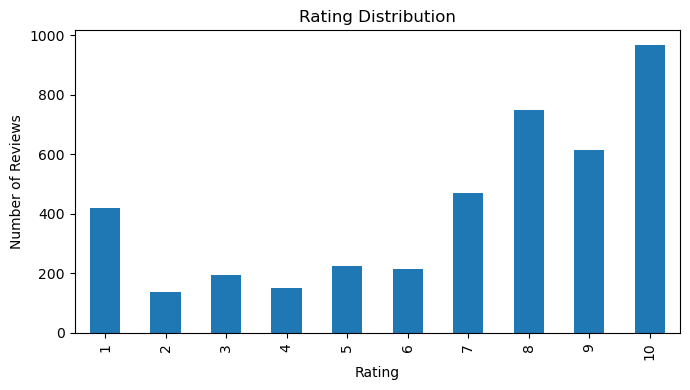

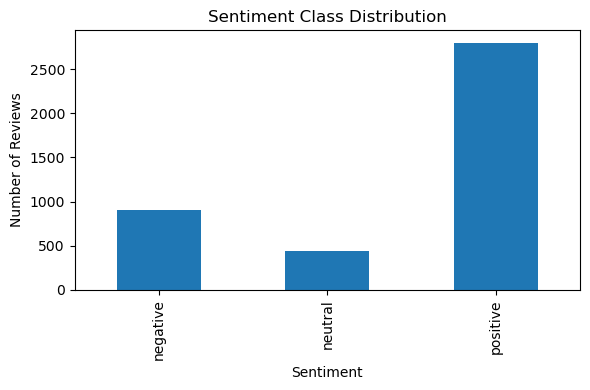

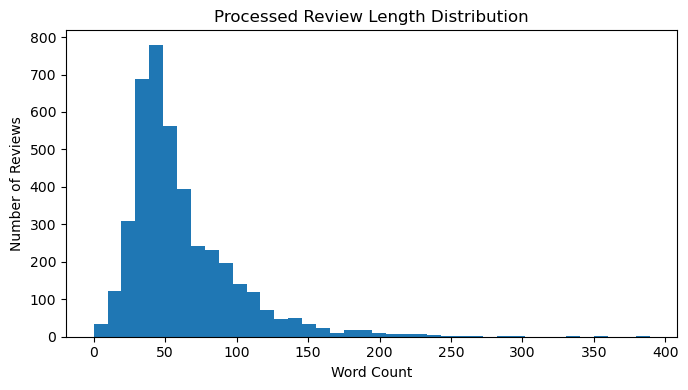

In [10]:
OUTPUT_FIG_DIR = "data/druglib_outputs/figures"
OUTPUT_TABLE_DIR = "data/druglib_outputs/tables"
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)
os.makedirs(OUTPUT_TABLE_DIR, exist_ok=True)

plt.figure(figsize=(7, 4))
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FIG_DIR, "rating_distribution.png"), dpi=150)
plt.show()

plt.figure(figsize=(6, 4))
df["sentiment"].value_counts().reindex(["negative", "neutral", "positive"]).plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FIG_DIR, "sentiment_distribution.png"), dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
df["processed_word_count"].plot(kind="hist", bins=40)
plt.title("Processed Review Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FIG_DIR, "review_length_distribution.png"), dpi=150)
plt.show()


## 11. Top drugs, conditions, side effects and effectiveness categories

These tables help explain the dataset and identify common medical categories in the reviews.


In [11]:
top_drugs = df["urlDrugName"].value_counts().head(15).reset_index()
top_drugs.columns = ["drug_name", "count"]

top_conditions = df["condition"].value_counts().head(15).reset_index()
top_conditions.columns = ["condition", "count"]

side_effects_dist = df["sideEffects"].value_counts().reset_index()
side_effects_dist.columns = ["side_effect_severity", "count"]

effectiveness_dist = df["effectiveness"].value_counts().reset_index()
effectiveness_dist.columns = ["effectiveness", "count"]

display(top_drugs)
display(top_conditions)
display(side_effects_dist)
display(effectiveness_dist)

top_drugs.to_csv(os.path.join(OUTPUT_TABLE_DIR, "top_drugs.csv"), index=False)
top_conditions.to_csv(os.path.join(OUTPUT_TABLE_DIR, "top_conditions.csv"), index=False)
side_effects_dist.to_csv(os.path.join(OUTPUT_TABLE_DIR, "side_effects_distribution.csv"), index=False)
effectiveness_dist.to_csv(os.path.join(OUTPUT_TABLE_DIR, "effectiveness_distribution.csv"), index=False)


,drug_name,count
0,lexapro,74
1,paxil,58
2,retin-a,55
3,synthroid,53
4,zoloft,52
5,prozac,51
6,effexor,46
7,effexor-xr,46
8,chantix,44
9,accutane,44


,condition,count
0,depression,302
1,acne,211
2,anxiety,90
3,insomnia,75
4,birth control,68
5,high blood pressure,62
6,allergies,49
7,migraine,44
8,add,41
9,asthma,41


,side_effect_severity,count
0,Mild Side Effects,1349
1,No Side Effects,1198
2,Moderate Side Effects,850
3,Severe Side Effects,491
4,Extremely Severe Side Effects,255


,effectiveness,count
0,Highly Effective,1741
1,Considerably Effective,1238
2,Moderately Effective,572
3,Ineffective,329
4,Marginally Effective,263


## 12. Vocabulary analysis

This section calculates vocabulary size and the most common words after preprocessing.


In [12]:
all_tokens = [token for tokens in df["tokens"] for token in tokens]
token_counts = Counter(all_tokens)

vocab_size = len(token_counts)
total_tokens = len(all_tokens)

print("Vocabulary size:", vocab_size)
print("Total processed tokens:", total_tokens)

top_words = pd.DataFrame(token_counts.most_common(30), columns=["term", "count"])
display(top_words)

top_words.to_csv(os.path.join(OUTPUT_TABLE_DIR, "top_words.csv"), index=False)


Vocabulary size: 13768
Total processed tokens: 255156


,term,count
0,day,3990
1,not,3871
2,effect,3137
3,side,2671
4,take,2443
5,taking,2278
6,time,2123
7,drug,2079
8,pain,1847
9,medication,1775


## 13. Save processed files

The processed files are saved for the next notebooks.  
They include the original columns plus full_review, clean_review, tokens, processed_review, sentiment and length features.


In [13]:
PROCESSED_DIR = "data/druglib_outputs/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

processed_combined_path = os.path.join(PROCESSED_DIR, "druglib_processed_combined.csv")
processed_train_path = os.path.join(PROCESSED_DIR, "druglib_processed_train.csv")
processed_test_path = os.path.join(PROCESSED_DIR, "druglib_processed_test.csv")

# Convert tokens to a string-friendly version for CSV storage.
df_to_save = df.copy()
df_to_save["tokens"] = df_to_save["tokens"].apply(lambda tokens: " ".join(tokens))

df_to_save.to_csv(processed_combined_path, index=False)
df_to_save[df_to_save["split"] == "train"].to_csv(processed_train_path, index=False)
df_to_save[df_to_save["split"] == "test"].to_csv(processed_test_path, index=False)

print("Saved:")
print(processed_combined_path)
print(processed_train_path)
print(processed_test_path)


Saved:
data/druglib_outputs/processed/druglib_processed_combined.csv
data/druglib_outputs/processed/druglib_processed_train.csv
data/druglib_outputs/processed/druglib_processed_test.csv


## 14. Part 1 summary

The preprocessing stage is complete because the notebook:

- loads and combines the raw train/test files,
- documents the dataset schema,
- checks missing values and duplicates,
- creates a full review text field,
- creates rating-based sentiment labels,
- cleans and tokenizes the text,
- removes stopwords while keeping negation words,
- lemmatizes tokens,
- creates EDA visuals and vocabulary summaries,
- and saves processed datasets for later modeling and retrieval.
